# Data exploration of collision_dataset.txt
An exploration of the dataset generated by Benjamin Vollebregt using CTC simulations for two colliding $H_2$ molecules.

## Info

### Dataset explanation

collision_dataset.txt contains 10.000 the translational and rotational energies of two colliding particles for 10.000 simulations.

There are 7 columns containing the following:

'b' = impact parameter

'Etr' = precollisional translational kinetic energy of particle 1 + translational kinetic energy of particle 2 [in Kelvin]. Both particles start with equal velocity so $Etr_A = Etr_B = 0.5 Etr$.

'Er1' = precollisional rotational kinetic energy of particle 1

'Er2' = precollisional rotational kinetic energy of particle 2

'Etrp'= postcollisional translational kinetic energy of particle 1 + translational kinetic energy of particle 2 [in Kelvin]

'Er1p' = postcollisional rotational kinetic energy of particle 1

'Er2p' = postcollisional rotational kinetic energy of particle 2

### Initial inspection

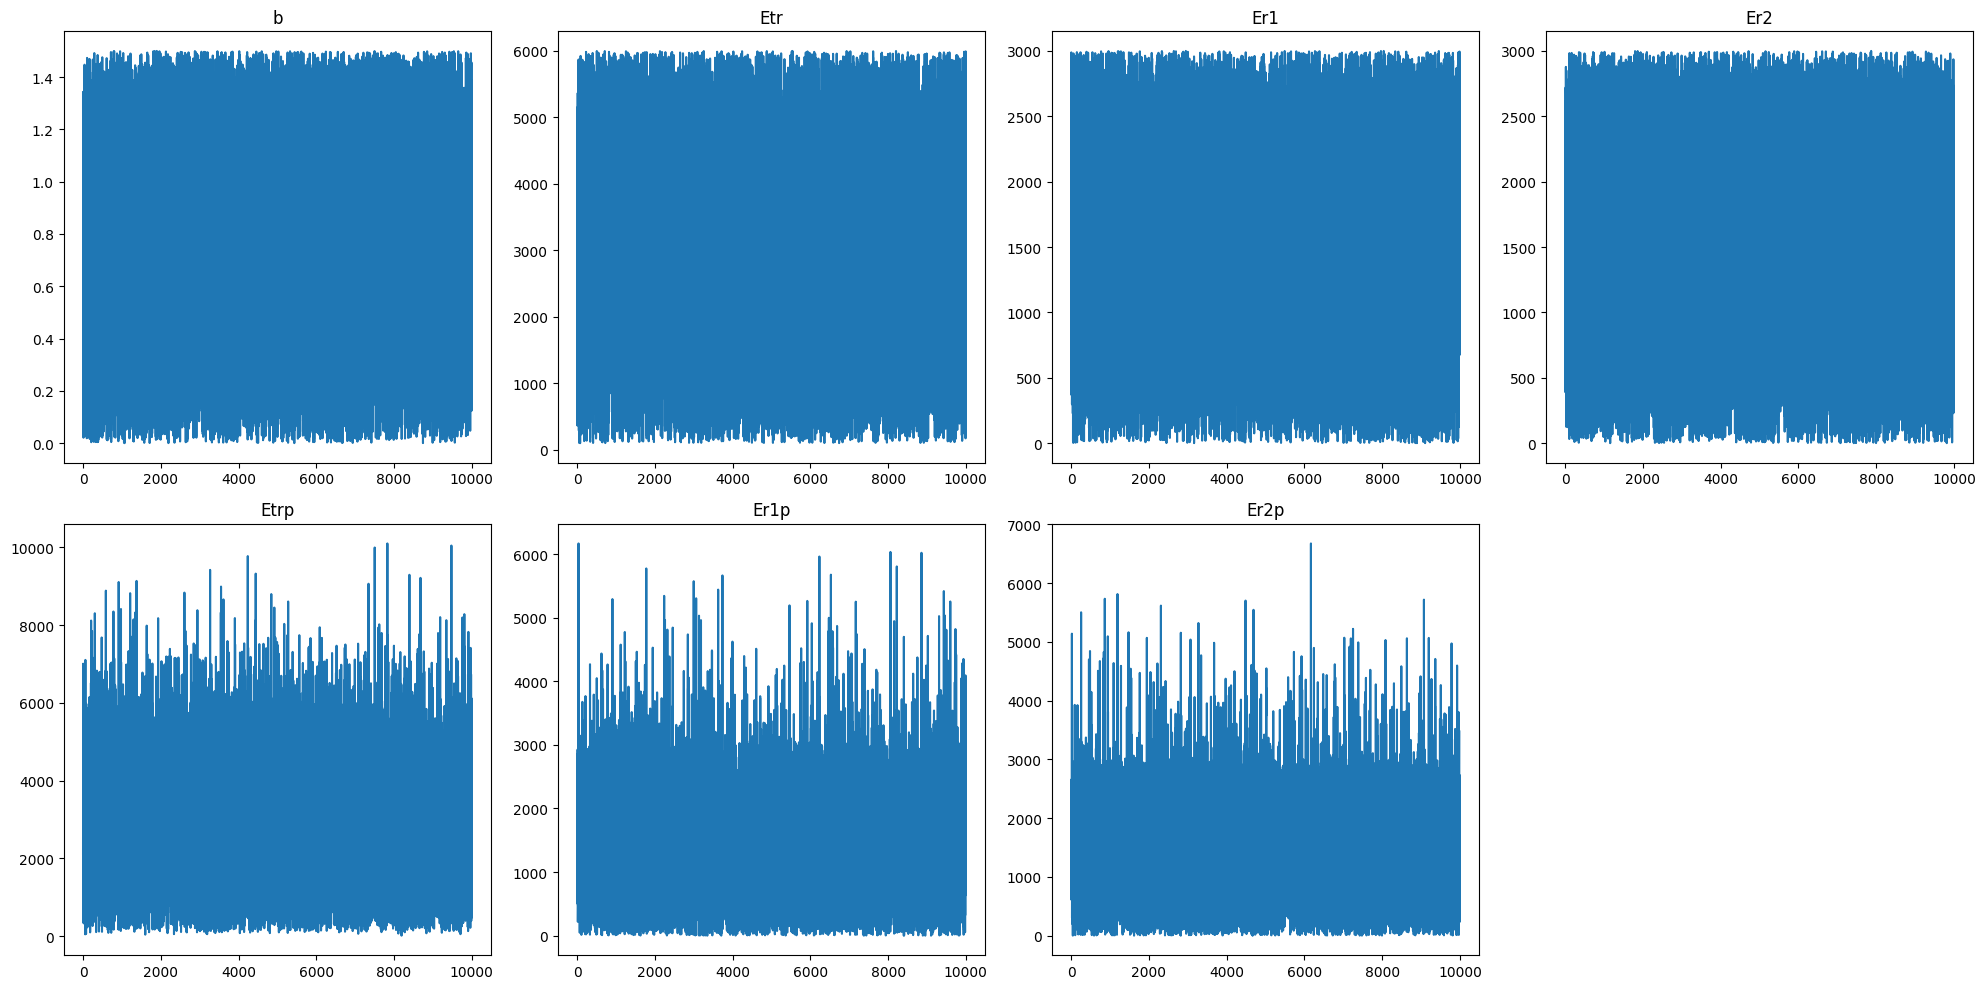

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Visualy inspect collision dataset

data_path = 'collision_dataset.txt'

collision_df = pd.read_csv(data_path, header=0)

fig, ax = plt.subplots(2,4)
fig.set_size_inches(20, 10)

for i in range(len(collision_df.columns)):
    ax[i//4, i%4].plot(collision_df.iloc[:,i])
    ax[i//4, i%4].set_title(collision_df.columns[i])

ax[1,3].axis('off')  # Hide unused subplot

plt.tight_layout()
plt.show()


### Check total energies

Check if total pre-collisional energies are equal to total post-collisional energies.

> Question: is the collision instantaneous? If so, then the total energy right before and right after collision should be equal to one another.

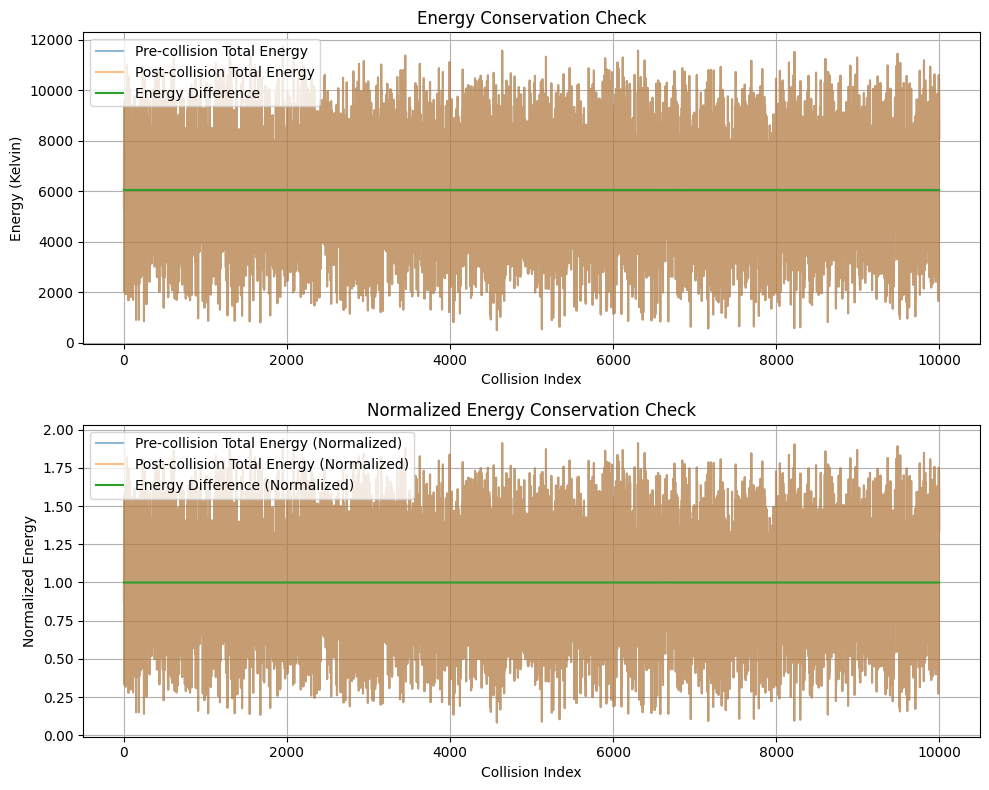

In [22]:

Delta_E= collision_df.loc[:,['Etr','Er1','Er2']].sum(axis=1) - collision_df.loc[:,['Etrp','Er1p','Er2p']].sum(axis=1)
fig, ax = plt.subplots(2,1)
fig.set_size_inches(10, 8)

# Plot energies and energy difference
ax[0].plot(collision_df.loc[:,['Etr', 'Er1', 'Er2']].sum(axis=1), alpha=0.5, label='Pre-collision Total Energy')
ax[0].plot(collision_df.loc[:,['Etrp', 'Er1p', 'Er2p']].sum(axis=1), alpha=0.5, label='Post-collision Total Energy')
ax[0].plot(Delta_E + collision_df.loc[:,['Etr', 'Er1', 'Er2']].sum(axis=1).mean(axis=0), label='Energy Difference')
ax[0].set_xlabel('Collision Index')
ax[0].set_ylabel('Energy (Kelvin)')
ax[0].set_title('Energy Conservation Check')
ax[0].legend()
ax[0].grid()

# Plot normalized energies and energy difference
ax[1].plot(collision_df.loc[:,['Etr', 'Er1', 'Er2']].sum(axis=1) / collision_df.loc[:,['Etr', 'Er1', 'Er2']].sum(axis=1).mean(axis=0), alpha=0.5, label='Pre-collision Total Energy (Normalized)')
ax[1].plot(collision_df.loc[:,['Etrp', 'Er1p', 'Er2p']].sum(axis=1) / collision_df.loc[:,['Etr', 'Er1', 'Er2']].sum(axis=1).mean(axis=0), alpha=0.5, label='Post-collision Total Energy (Normalized)')
ax[1].plot((Delta_E + collision_df.loc[:,['Etr','Er1','Er2']].sum(axis=1).mean(axis=0)) / collision_df.loc[:,['Etr', 'Er1', 'Er2']].sum(axis=1).mean(axis=0), label='Energy Difference (Normalized)')
ax[1].set_xlabel('Collision Index')
ax[1].set_ylabel('Normalized Energy')
ax[1].set_title('Normalized Energy Conservation Check')
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()